In [4]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [16]:
train = r"C:\Users\kaige\python projects\Deep Learning\dc\dogvscat_small\train"
trainDataGen = ImageDataGenerator(rescale = 1 / 255, rotation_range = 20, width_shift_range = 0.2, height_shift_range = 0.2, shear_range = 0.2, zoom_range = 0.2, horizontal_flip = True)
val_test_datagen = ImageDataGenerator(rescale = 1/255)
trainData = trainDataGen.flow_from_directory(train, target_size = (200, 200), batch_size = 32, class_mode = "binary")

Found 2000 images belonging to 2 classes.


In [17]:
val_dir = r"C:\Users\kaige\python projects\Deep Learning\dc\dogvscat_small\validation"
test = r"C:\Users\kaige\python projects\Deep Learning\dc\dogvscat_small\test"
val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(200, 200),
    batch_size=32,
    class_mode='binary'
)

test_data = val_test_datagen.flow_from_directory(
    test,
    target_size=(200, 200),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [18]:
sequential = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(200,200,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid')
])

c:\Users\kaige\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
sequential.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = sequential.fit(trainData, epochs=10, validation_data = val_data)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.5075 - loss: 0.6971

c:\Users\kaige\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 58s 897ms/step - accuracy: 0.5145 - loss: 0.6957 - val_accuracy: 0.5440 - val_loss: 0.6911
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 645ms/step - accuracy: 0.5100 - loss: 0.6932 - val_accuracy: 0.5780 - val_loss: 0.6870
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 656ms/step - accuracy: 0.5500 - loss: 0.6899 - val_accuracy: 0.5040 - val_loss: 0.6976
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 618ms/step - accuracy: 0.5425 - loss: 0.6855 - val_accuracy: 0.5610 - val_loss: 0.6711
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 586ms/step - accuracy: 0.6100 - loss: 0.6655 - val_accuracy: 0.6210 - val_loss: 0.6600
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 577ms/step - accuracy: 0.5765 - loss: 0.6780 - val_accuracy: 0.5910 - val_loss: 0.6973
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 584ms/step - accuracy: 0.5970 - loss: 0.6699 - val_accuracy: 0.6260 - val_loss: 0.6341
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 579ms/step - accuracy: 0.6250 - loss: 0.6482 - val_accuracy: 0.667

In [21]:
sequential.save("dog_cat_model.h5")

In [5]:
Sequential = load_model("dog_cat_model.h5")

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step


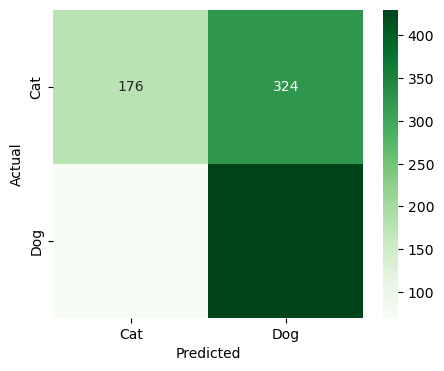

In [24]:
predictions = (sequential.predict(test_data) > 0.5).astype(int)
true_labels = test_data.classes

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap = "Greens",
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## Transfer Learning ##

In [6]:
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.models import Model

base_model = VGG16(weights = "imagenet", include_top = False, input_shape = (200, 200, 3))

base_model.layers

[<InputLayer name=input_layer_1, built=True>,
 <Conv2D name=block1_conv1, built=True>,
 <Conv2D name=block1_conv2, built=True>,
 <MaxPooling2D name=block1_pool, built=True>,
 <Conv2D name=block2_conv1, built=True>,
 <Conv2D name=block2_conv2, built=True>,
 <MaxPooling2D name=block2_pool, built=True>,
 <Conv2D name=block3_conv1, built=True>,
 <Conv2D name=block3_conv2, built=True>,
 <Conv2D name=block3_conv3, built=True>,
 <MaxPooling2D name=block3_pool, built=True>,
 <Conv2D name=block4_conv1, built=True>,
 <Conv2D name=block4_conv2, built=True>,
 <Conv2D name=block4_conv3, built=True>,
 <MaxPooling2D name=block4_pool, built=True>,
 <Conv2D name=block5_conv1, built=True>,
 <Conv2D name=block5_conv2, built=True>,
 <Conv2D name=block5_conv3, built=True>,
 <MaxPooling2D name=block5_pool, built=True>]

In [ ]:
for i in base_model.layers:
    i.trainable = False
model_output = base_model.output
model_output = Flatten()(model_output)
model_output = Dense(128, activation = "relu")(model_output)
model_output = Dropout(0.3)(model_output)
model_output = Dense(2, activation = "sigmoid")(model_output)
SequentialTL = Model(inputs = base_model.input, outputs = model_output)